In [1]:
import pandas as pd
import numpyro
numpyro.set_host_device_count(8)
numpyro.enable_x64()

In [2]:
df = pd.read_csv("data/cleaned_data.csv").set_index("date")
df.index = pd.to_datetime(df.index)
df

,number,winners,page,pédantix,pedantix,cémantix,cemantix
date,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0
...,...,...,...,...,...,...,...
2025-11-04,1271,33282,Premier Empire bulgare,16.0,23.0,31.0,95.0
2025-11-05,1272,36303,Violon,13.0,19.0,30.0,95.0
2025-11-06,1273,38471,Fée,16.0,24.0,27.0,90.0


In [3]:
total_weeks = len(df.resample("W"))
print(f"Total weeks: {total_weeks}")

Total weeks: 183


In [6]:
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from jax import random
import jax.numpy as jnp
import numpyro.distributions as dist
import arviz as az
import jax
from numpyro.infer import init_to_median


def logistic(t, norm, start, rate_rise):
    return norm * jax.lax.logistic(rate_rise*(t - start))

def model(observed=True, n=3):

    obs_pedantix = jnp.asarray(df["pédantix"].resample("W").sum().values, dtype=jnp.int32)

    norm = numpyro.sample("norm", dist.Uniform( -70. * jnp.ones(n), +70. * jnp.ones(n)))
    time = numpyro.sample("_time", dist.Uniform( 0 * jnp.ones(n), 1.2 * jnp.ones(n)))
    time = jnp.cumsum(time) / (n-1) * total_weeks
    start = numpyro.deterministic("start", time)

    rate_rise = 10 * jnp.ones(n)

    rate_rise = rate_rise.at[1:].set(
        numpyro.sample(
            "rate_rise",
            dist.HalfCauchy(0.1 * jnp.ones(n - 1)))
    )

    simulation = jax.vmap(lambda t : logistic(t, norm, start, rate_rise))(jnp.arange(total_weeks)).sum(axis=-1)

    mu = jnp.clip(simulation, 1e-6, jnp.inf)

    # Overdispersion parameter (phi): smaller -> wider than Poisson, larger -> ~Poisson
    phi = numpyro.sample("phi", dist.LogNormal(jnp.log(100.0), 1.0))

    numpyro.sample(
        "obs_pedantix",
        dist.NegativeBinomial2(mean=mu, concentration=phi),
        obs=obs_pedantix if observed else None,
    )

mcmc = MCMC(
    NUTS(
        model,
        init_strategy=init_to_median(num_samples=1_000),
        dense_mass=True,
        target_accept_prob=0.95
    ),
    num_chains=8,
    num_warmup=50_000,
    num_samples=10_000
)

rng_key = random.PRNGKey(0)
mcmc.run(rng_key)

posterior_samples = mcmc.get_samples()

posterior_predictive = Predictive(model, posterior_samples)(
    random.PRNGKey(1), observed=False
)

inference_data = az.from_numpyro(
    mcmc,
    posterior_predictive=posterior_predictive
)

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

  0%|          | 0/60000 [00:00<?, ?it/s]

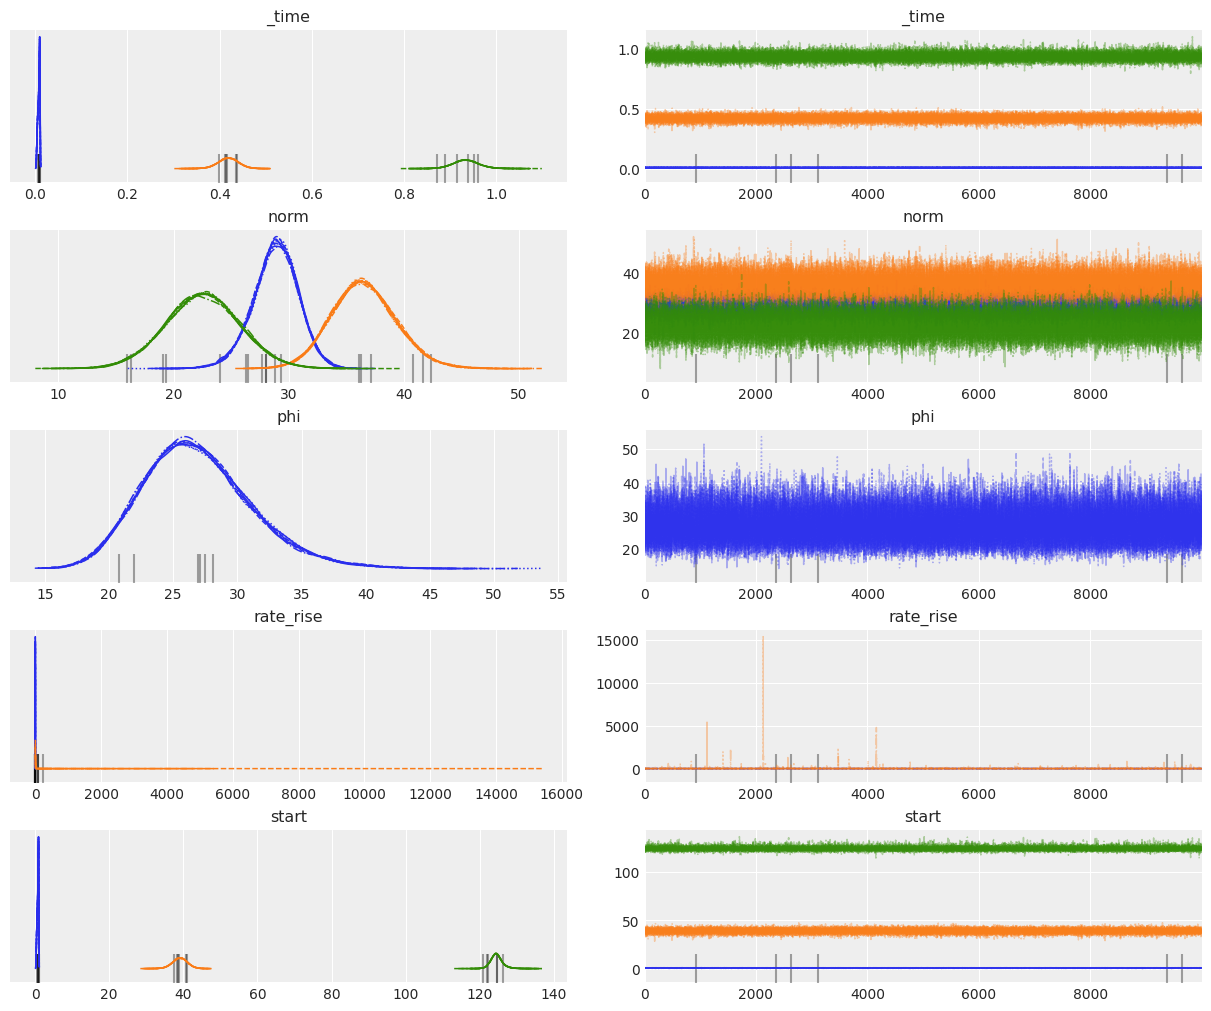

In [7]:
with az.style.context("arviz-darkgrid", after_reset=True):
    az.plot_trace(inference_data, compact=True)

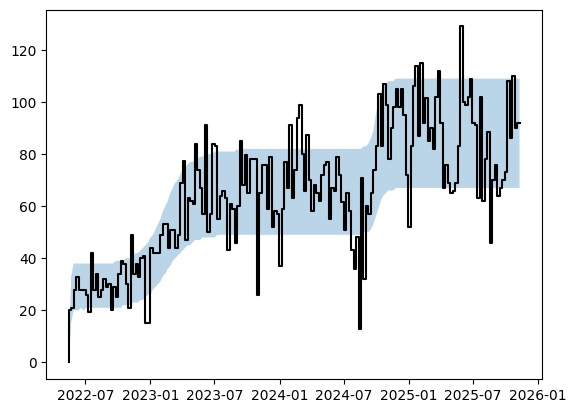

In [8]:
import numpy as np
import matplotlib.pyplot as plt

winners = np.asarray(az.extract(inference_data, "posterior_predictive", var_names=["obs_pedantix"]))
observed_winners = df["pédantix"].resample("W").sum()
plt.step(observed_winners.index, observed_winners, color="black")
plt.fill_between(observed_winners.index, *np.percentile(winners, [14, 86], axis=1), alpha=0.3)
plt.show()

In [9]:
import pandas as pd
import plotly.express as px
import cmasher as cmr
from matplotlib.colors import to_hex  # to convert cmasher RGB -> hex for Plotly

df = df.copy()
df.index = pd.to_datetime(df.index)

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["weekday"] = pd.Categorical(df.index.day_name(), categories=weekday_order, ordered=True)

df_long = (
    df.reset_index(names="Time")
      .melt(
          id_vars=["Time", "weekday"],
          value_vars=["pédantix", "cémantix"],
          var_name="term",
          value_name="value"
      )
)

colors = [to_hex(c) for c in cmr.take_cmap_colors(cmr.neon, 7)]

fig = px.histogram(
    df_long,
    x="value",
    color="weekday",
    facet_col="term",
    barmode="overlay",
    opacity=0.45,
    histnorm="probability density",
    category_orders={"weekday": weekday_order, "term": ["pédantix", "cémantix"]},
    color_discrete_sequence=colors,
)

fig.update_traces(xbins=dict(start=0, end=100, size=1))

fig.update_xaxes(range=[0, 33])
fig.update_yaxes(range=[0, 0.4])
fig.update_layout(
    width=950, height=360,
    bargap=0.05,
    title="Histograms by weekday",
    legend_title_text="Weekday",
)

fig.show()

In [ ]:
import numpyro
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from jax import random
import arviz as az

def model():

    weekly_zeros_pedantix = numpyro.sample("weekly_zeros_pedantix", dist.Uniform(jnp.zeros(7), jnp.ones(7)))
    weekly_zeros_cemantix = numpyro.sample("weekly_zeros_cemantix", dist.Uniform(jnp.zeros(7), jnp.ones(7)))
    weekly_rates = numpyro.sample("weekly_rates", dist.Uniform(jnp.zeros(7), 50*jnp.ones(7)))
    ratio_pedantix_cemantix_search = numpyro.sample("log_ratio", dist.Uniform(-4, 4))

    for i, name in enumerate(weekday_names):
        filtered = df[df.index.dayofweek == i]

        numpyro.sample(
            f"{name}_pédantix_observed",
            dist.ZeroInflatedPoisson(
                weekly_zeros_pedantix[i],
                weekly_rates[i] * jnp.exp(ratio_pedantix_cemantix_search)
            ),
            obs=jnp.asarray(filtered["pédantix"])
        )

        numpyro.sample(
            f"{name}_cémantix_observed",
            dist.ZeroInflatedPoisson(
                weekly_zeros_cemantix[i],
                weekly_rates[i]
            ),
            obs=jnp.asarray(filtered["cémantix"])
        )

mcmc = MCMC(NUTS(model), num_chains=8, num_warmup=1000, num_samples=1000)
rng_key = random.PRNGKey(0)
mcmc.run(rng_key)
inference_data = az.from_numpyro(mcmc)

In [ ]:
with az.style.context("arviz-darkgrid", after_reset=True):
    az.plot_trace(inference_data, compact=True);